In [ ]:
"""
my bagging: classification and regression examples by bagging
"""

'\nmy bagging: classification and regression examples by bagging\n'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes, load_linnerud
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn import metrics
from scipy.stats import mode as moda

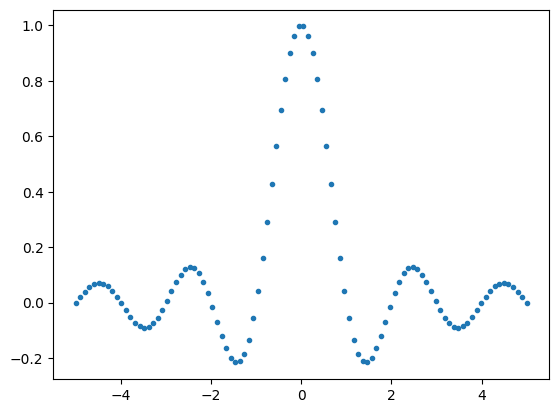

In [ ]:
# Prepare and show dataset(s)
# X, y = load_boston(return_X_y=True)
# X, y = load_diabetes(return_X_y=True)
X = np.linspace(-5, 5, 100)[:, None]
y = np.sinc(X)
# plt.clf(), plt.plot(X, y, 'o')
for i in np.arange(X.shape[1]):
    # plt.subplot(5,3,i+1),
    plt.plot(X[:,i], y, '.', label='Test')

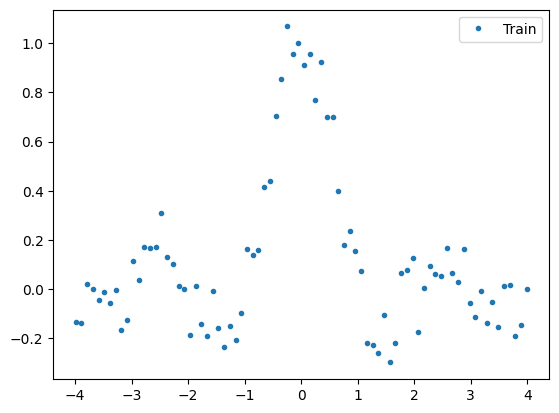

In [ ]:
# For the sinc
pcut = 4
noise = 0.1
Xtr = X[(-pcut <= X) & (X <= pcut)][:, None]
ytr = y[(-pcut <= X) & (X <= pcut)][:, None]
ytr = ytr + noise * np.random.randn(ytr.shape[0], 1)
Xts = X; yts = y
plt.plot(Xtr, ytr, '.', label='Train')
plt.legend()

In [ ]:
predictor = DecisionTreeRegressor
# predictor = LinearRegression
criterion = 'squared_error'
max_depth = 4  # None for max
report = metrics.mean_squared_error

# Create a single predictor (for reference)
dt = predictor(criterion=criterion,
               max_depth=max_depth, random_state=0)

In [ ]:
# Train / prediction of single predictor
dt.fit(Xtr, ytr)
yp = dt.predict(Xts)
print('Res tree:', report(yts, yp))

Res tree: 0.005931654338162212


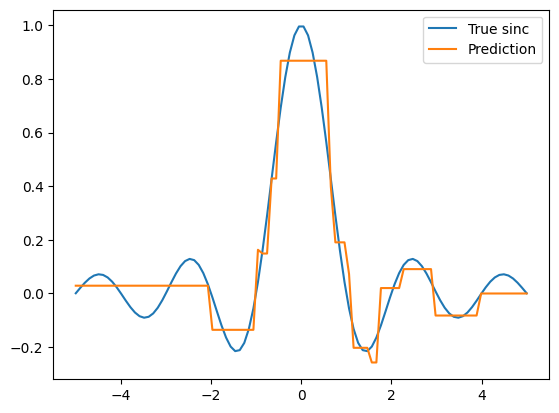

In [ ]:
# Show results graphically
plt.figure()
plt.plot(Xts, yts, label='True sinc')
plt.plot(Xts, yp, label='Prediction')
plt.legend()

In [ ]:
####################
#### SOLUTION
####################

#%% Train bagging ensemble
T = 200
# bag  variable to store the trees (for ex., a list)
bag = []
# loop for the number of trees
for t in range(T):
    xx, yy = resample(Xtr, ytr, replace=True)
    pred = predictor(criterion=criterion,
                     max_depth=max_depth)
    pred.fit(xx, yy)
    bag.append(pred)

In [ ]:
# Test
# Obtain T predictions
yb = np.zeros((T, len(yts)))
for n, t in enumerate(bag):
    yb[n,:] = t.predict(Xts)

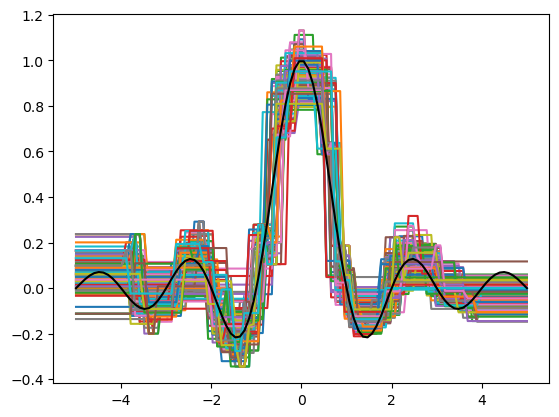

In [ ]:
# Evaluate and compare results
plt.figure()
plt.plot(Xts, yb.T, label='Predictions')
plt.plot(Xts, yts, 'k-',label='True sinc')


In [ ]:
# For classification, majority vote (or mode => scipy stats.mode)
yf = np.mean(yb, axis=0)

Res bag:  0.004416882721365235


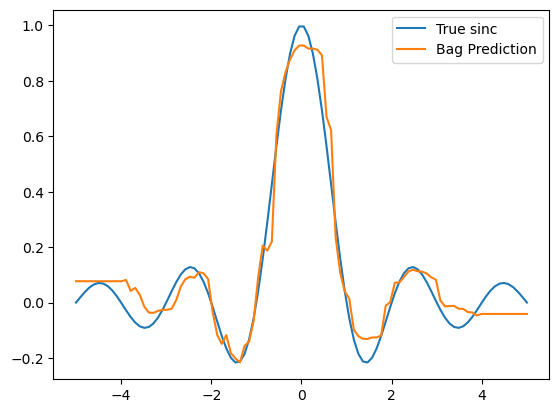

In [ ]:
# Evaluate and compare results
print('Res bag: ', report(yts, yf))
plt.figure()
plt.plot(Xts, yts, label='True sinc')
plt.plot(Xts, yf, label='Bag Prediction')
plt.legend()